Dataset loaded from: Ini23NovFin30Abril.csv
Dataset dimensions: (160, 28)


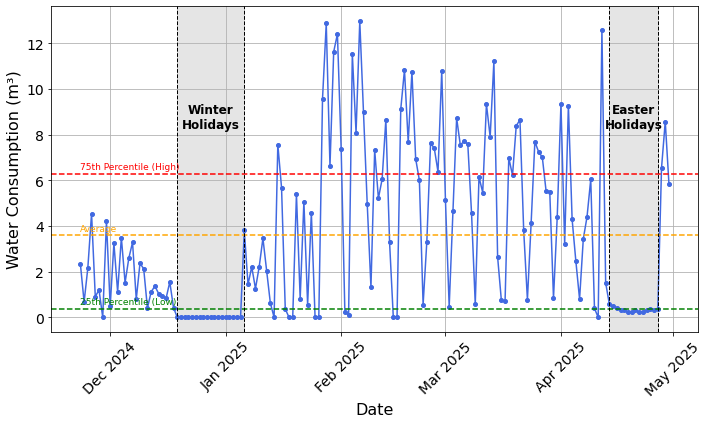

Figure saved to: /Users/martinluna/Dropbox/UASLP/Tutoria/Maestria/Baez Salazar Luis Eduardo/Datos/results/Figure_1_Daily_Water_Consumption.png


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

# Detect the repository root
current_dir = Path.cwd()

if (current_dir / "data").exists():
    repository_root = current_dir
elif (current_dir.parent / "data").exists():
    repository_root = current_dir.parent
else:
    raise FileNotFoundError(
        "The repository data directory could not be found. "
        "Run the notebook from the repository root or from the notebooks directory."
    )

# Repository paths
data_path = repository_root / "data" / "Ini23NovFin30Abril.csv"
results_dir = repository_root / "results"
results_dir.mkdir(parents=True, exist_ok=True)

# Verify that the dataset exists
if not data_path.exists():
    raise FileNotFoundError(
        f"Dataset not found: {data_path}\n"
        "Please place Ini23NovFin30Abril.csv inside the data directory."
    )
    
# Load and prepare the dataset
df = pd.read_csv(data_path)
print(f"Dataset loaded from: {data_path.name}")
print(f"Dataset dimensions: {df.shape}")

df["Fecha"] = pd.to_datetime(df["Fecha"], dayfirst=True)
df = df.loc[:, ~df.columns.str.contains(r"^Unnamed")]

# Statistical reference values
q1 = df["Consumo"].quantile(0.25)
mean_consumption = df["Consumo"].mean()
q3 = df["Consumo"].quantile(0.75)

# Holiday periods
winter_start = pd.to_datetime("2024-12-19")
winter_end = pd.to_datetime("2025-01-06")
easter_start = pd.to_datetime("2025-04-14")
easter_end = pd.to_datetime("2025-04-27")

# Create the figure
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    df["Fecha"],
    df["Consumo"],
    linestyle="-",
    marker="o",
    markersize=4,
    color="royalblue"
)

# Statistical thresholds
ax.axhline(q1, color="green", linestyle="--", linewidth=1.5)
ax.axhline(mean_consumption, color="orange", linestyle="--", linewidth=1.5)
ax.axhline(q3, color="red", linestyle="--", linewidth=1.5)

ax.text(
    df["Fecha"].min(),
    q1 + 0.2,
    "25th Percentile (Low)",
    color="green",
    fontsize=9
)

ax.text(
    df["Fecha"].min(),
    mean_consumption + 0.2,
    "Average",
    color="orange",
    fontsize=9
)

ax.text(
    df["Fecha"].min(),
    q3 + 0.2,
    "75th Percentile (High)",
    color="red",
    fontsize=9
)

# Holiday periods
for date in [winter_start, winter_end, easter_start, easter_end]:
    ax.axvline(date, color="black", linestyle="--", linewidth=1)

ax.axvspan(winter_start, winter_end, color="gray", alpha=0.2)
ax.axvspan(easter_start, easter_end, color="gray", alpha=0.2)

ax.text(
    winter_start + (winter_end - winter_start) / 2,
    q3 + 2,
    "Winter\nHolidays",
    fontsize=12,
    weight="bold",
    ha="center"
)

ax.text(
    easter_start + (easter_end - easter_start) / 2,
    q3 + 2,
    "Easter\nHolidays",
    fontsize=12,
    weight="bold",
    ha="center"
)

# Axis formatting
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())

ax.set_xlabel("Date", fontsize=16)
ax.set_ylabel("Water Consumption (m³)", fontsize=16)
ax.tick_params(axis="both", labelsize=14)
ax.tick_params(axis="x", rotation=45)
ax.grid(True)

fig.tight_layout()

output_path = results_dir / "Figure_1_Daily_Water_Consumption.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved to: {output_path}")
